# Introduction

This notebook walks throught the production of Fig. 01, which shows the spectra of winds and currents across a year of model output. The currents are decomposed into their vortical and divergent components. Statistically significant peaks are indentified in the divergent component of the currents. Confidence intervals are estimated form a chi-2 distribution considering a 1-week decorrelation scale (see `../analysis/decorrelation_scale.ipynb`).

## Imports

In [2]:
import sys
sys.path.append("../src")

In [3]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from spec_plot import (
    plot_spectra_2panel,
    add_spectral_slope,
)

from spectral_analysis import (
    CI,
    isotropize,
)

plt.rcdefaults()
plt.style.use("../src/paper.mplstyle")

# Data

In [4]:
INPUT_DIR = Path('../data/spectra/')

For this figure, we will plot the spectra of the low-variability winds (LVWD), highv-variability winds (HVWD), currents (CUR), and rotationa and divergent components of the currents.

In [5]:
ww3_lvwd = xr.open_zarr(INPUT_DIR / 'lvwd.zarr', consolidated=False)
ww3_hvwd = xr.open_zarr(INPUT_DIR / 'hvwd.zarr', consolidated=False)
ww3_lvwd_cur = xr.open_zarr(INPUT_DIR / 'lvwd_cur.zarr', consolidated=False)

cur_decomp = xr.open_zarr(INPUT_DIR / 'helmholtz_decomp.zarr', consolidated=False)

# Mean 1D Spectra and Error Estimation

We first take the data above (which is 2D spectra at each timestep for each component of the vector) and compute the vector variance spectrum, take the mean across time, and isotropize (take the azimuthal average). The spectra of the rotation and divergent components are divided by 2 to make KE spectra vector varianace spectra for consistency.

In [8]:
lvwd_vecspec = (ww3_lvwd.uwnd_PSD + ww3_lvwd.vwnd_PSD)
hvwd_vecspec = (ww3_hvwd.uwnd_PSD + ww3_hvwd.vwnd_PSD)

cur_vecspec = (ww3_lvwd_cur.ucur_PSD + ww3_lvwd_cur.vcur_PSD)
cur_div_vecspec = cur_decomp.div_KE_psd/2
cur_rot_vecspec = cur_decomp.rot_KE_psd/2

In [9]:
mean_lvwd_vecspec = lvwd_vecspec.mean(dim='time')
mean_hvwd_vecspec = hvwd_vecspec.mean(dim='time')

mean_cur_vecspec = cur_vecspec.mean(dim='time')
mean_cur_div_vecspec = cur_div_vecspec.mean(dim='time')
mean_cur_rot_vecspec = cur_rot_vecspec.mean(dim='time')

In [10]:
mean_iso_lvwd_vecspec = isotropize(mean_lvwd_vecspec)
mean_iso_hvwd_vecspec = isotropize(mean_hvwd_vecspec)

mean_iso_cur_vecspec = isotropize(mean_cur_vecspec)
mean_iso_cur_div_vecspec = isotropize(mean_cur_div_vecspec)
mean_iso_cur_rot_vecspec = isotropize(mean_cur_rot_vecspec)

We estimate error from the chi-2 distribution. The data is hourly, however the number of degrees of freedom for the chi-2 distribution needs to take into consideration the timescale at which a given variable becomes decorrelated with itself. See `../analysis/decorrelation_scale.ipynb` for the analysis done to compute the decorrelation scale for each variable. For all wind, current, and wave variables, the decorrelation scale is O(days). So here, we used a decorrelation scale of 1 week for all variables as a conservative estimate of error.

In [11]:
M_1wk = ww3_lvwd.time.count() / 24 / 7

By default, the function computes 95% confidence intervals.

In [12]:
mean_iso_lvwd_vecspec = CI(mean_iso_lvwd_vecspec, M_1wk)
mean_iso_hvwd_vecspec = CI(mean_iso_hvwd_vecspec, M_1wk)

mean_iso_cur_vecspec = CI(mean_iso_cur_vecspec, M_1wk)
mean_iso_cur_div_vecspec = CI(mean_iso_cur_div_vecspec, M_1wk)
mean_iso_cur_rot_vecspec = CI(mean_iso_cur_rot_vecspec, M_1wk)

# Plotting

In [13]:
winds_fig = {
    "hvwd": {
        "data": mean_iso_hvwd_vecspec,
        "color": "goldenrod",
        "linestyle": "-",
        "label": "$\mathbf{U}_\mathrm{HVWD}$",
        "linewidth": 1.5,
        "plot_CI": True,
        "CI_alpha": 0.2,
    },
    "lvwd": {
        "data": mean_iso_lvwd_vecspec,
        "color": "goldenrod",
        "linestyle": "--",
        "label": "$\mathbf{U}_\mathrm{LVWD}$",
        "linewidth": 1.5,
        "plot_CI": True,
        "CI_alpha": 0.2,
    },
}

<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1305506/4028956304.py:6: SyntaxWarning: invalid escape sequence '\m'
  "label": "$\mathbf{U}_\mathrm{HVWD}$",
/tmp/ipykernel_1305506/4028956304.py:15: SyntaxWarning: invalid escape sequence '\m'
  "label": "$\mathbf{U}_\mathrm{LVWD}$",


The rotational and divergent components of the currents are scaled by 0.1 to make them easier to see. It does not affect their shape.

In [15]:
currents_fig = {
    "currents": {
        "data": mean_iso_cur_vecspec, # / cur_plt.spectrum.values[0],
        "color": "blue",
        "linestyle": "-",
        "label": "$\mathbf{U}_\mathrm{cur}$",
        "linewidth": 1.5,
        "plot_CI": True,
        "CI_alpha": 0.2,
    },
    "currents-rot": {
        "data": mean_iso_cur_rot_vecspec * 0.1, # / vort_plt.spectrum.values[0] * 0.1,
        "color": "navy",
        "linestyle": "--",
        "label": "$\mathbf{U}_\mathrm{rot}$",
        "linewidth": 1.5,
        "plot_CI": True,
        "CI_alpha": 0.2,
    },
    "currents-div": {
        "data": mean_iso_cur_div_vecspec * 0.1, # / div_plt.spectrum.values[0] * 0.1,
        "color": "royalblue",
        "linestyle": "-.",
        "label": "$\mathbf{U}_\mathrm{div}$",
        "linewidth": 1.5,
        "plot_CI": True,
        "CI_alpha": 0.2,
    },
}

<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\m'
<>:24: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\m'
<>:24: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1305506/2186740615.py:6: SyntaxWarning: invalid escape sequence '\m'
  "label": "$\mathbf{U}_\mathrm{cur}$",
/tmp/ipykernel_1305506/2186740615.py:15: SyntaxWarning: invalid escape sequence '\m'
  "label": "$\mathbf{U}_\mathrm{rot}$",
/tmp/ipykernel_1305506/2186740615.py:24: SyntaxWarning: invalid escape sequence '\m'
  "label": "$\mathbf{U}_\mathrm{div}$",


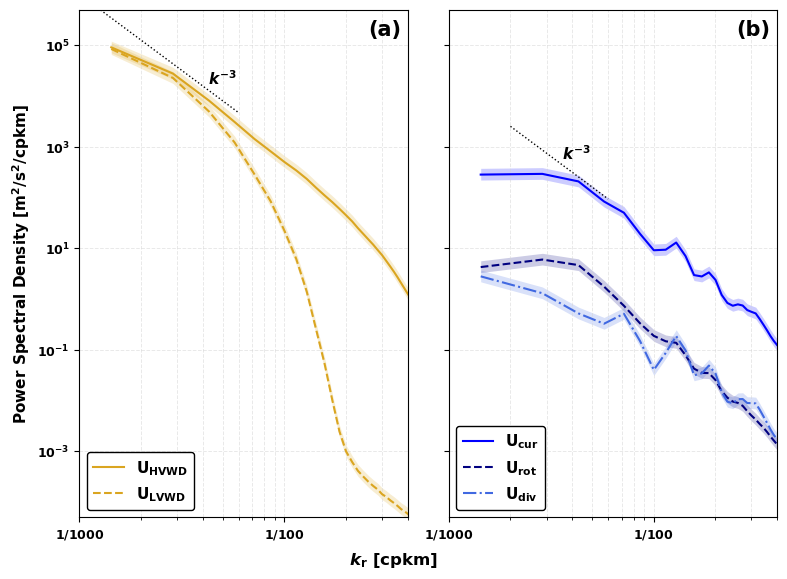

In [16]:
fig, axes = plot_spectra_2panel(
    winds_fig,
    currents_fig,
    titles=(None, None),
    xlims=(
        (1e-3, 1/25),
        (1e-3, 1/25),
    ),
    ylims=(
        (5e-5, 5e5),
        (5e-5, 5e5),
    ),
    ylab='Power Spectral Density [m$^2$/s$^2$/cpkm]',
    sharex=True,
    sharey=True,
    figsize=(8, 6),
    dpi=100,
    label_fontsize=15
)

# for kr in div_peaks.kr.values:
#     # vertical dashed line
#     axes[1].axvline(
#         kr,
#         color='black',
#         linestyle='--',
#         linewidth=0.8,
#         zorder=1,
#     )
    
#     # label as reciprocal wavelength-style wavenumber
#     axes[1].text(
#         kr * 1.04,
#         0.97,                        # near top of axis
#         f"1/{1/kr:.0f} cpkm",
#         transform=axes[1].get_xaxis_transform(),
#         rotation=90,
#         ha='center',
#         va='top',
#         fontsize=10,
#         color='black',
#         bbox=dict(facecolor='white', edgecolor='none', alpha=1, pad=0.5),
#         zorder = 2
#     )

# k^-3 slope on wind panel
add_spectral_slope(axes[0],slope=-3,
                   k_ref=1e-3,y_ref=1e6,
                   k_min=1e-3,k_max=6/1000,
                   label_k=5/1000,label_factor=1.8,
                   fontsize=11)

# k^-2 slope on current panel
add_spectral_slope(axes[1],slope=-3,
                   k_ref=1e-3,y_ref=2e4,
                   k_min=2/1000,k_max=6/1000,
                   label_k=4.2/1000,label_factor=1.8)

plt.show()

# Peaks

We note statistically significant (they lie outside the CI) peaks in the divergent component of the currents. We estimate where those are in `../analysis/peaks_in_div_currents.ipynb` and plot them here.